In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Loading datasets, augmenting training data

In [2]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image
from torch import nn, optim

# Define paths for train dataset
train_dir = '/content/drive/MyDrive/Master Folder/train'
val_dir = '/content/drive/MyDrive/Master Folder/valid'
test_dir = '/content/drive/MyDrive/Master Folder/test'
train_augmented_dir = '/content/drive/MyDrive/Master Folder/train_augmented'

transform = transforms.Compose([
    transforms.Resize((299, 299)),  # Resize images to 224x224 (adjust as needed)
    transforms.ToTensor(),          # Convert images to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize using ImageNet stats (can adjust)
])
"""
# Create a directory to store the augmented dataset
os.makedirs(train_augmented_dir, exist_ok=True)

# Define the augmentations
augmentation_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
])

# Function to save augmented images
def save_augmented_images(dataset, save_dir, num_augmentations=3):
    for class_name in dataset.classes:
        class_dir = os.path.join(save_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

    for idx, (img, label) in enumerate(dataset):
        class_name = dataset.classes[label]
        original_path = os.path.join(save_dir, class_name, f"original_{idx}.jpg")
        img.save(original_path)  # Save original image

        for i in range(num_augmentations):
            augmented_img = augmentation_transform(img)  # Apply augmentations
            augmented_path = os.path.join(save_dir, class_name, f"augmented_{idx}_{i}.jpg")
            augmented_img.save(augmented_path)

train_dataset = datasets.ImageFolder(root=train_dir)
save_augmented_images(train_dataset, train_augmented_dir, num_augmentations=3)
"""
train_augmented_dataset = datasets.ImageFolder(root=train_augmented_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(train_augmented_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print("Training dataset length:", len(train_augmented_dataset))
print("Validation dataset length:", len(val_dataset))
print("Test dataset length:", len(test_dataset))

Training dataset length: 4000
Validation dataset length: 36
Test dataset length: 38


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


# Visualizing samples of the training dataset

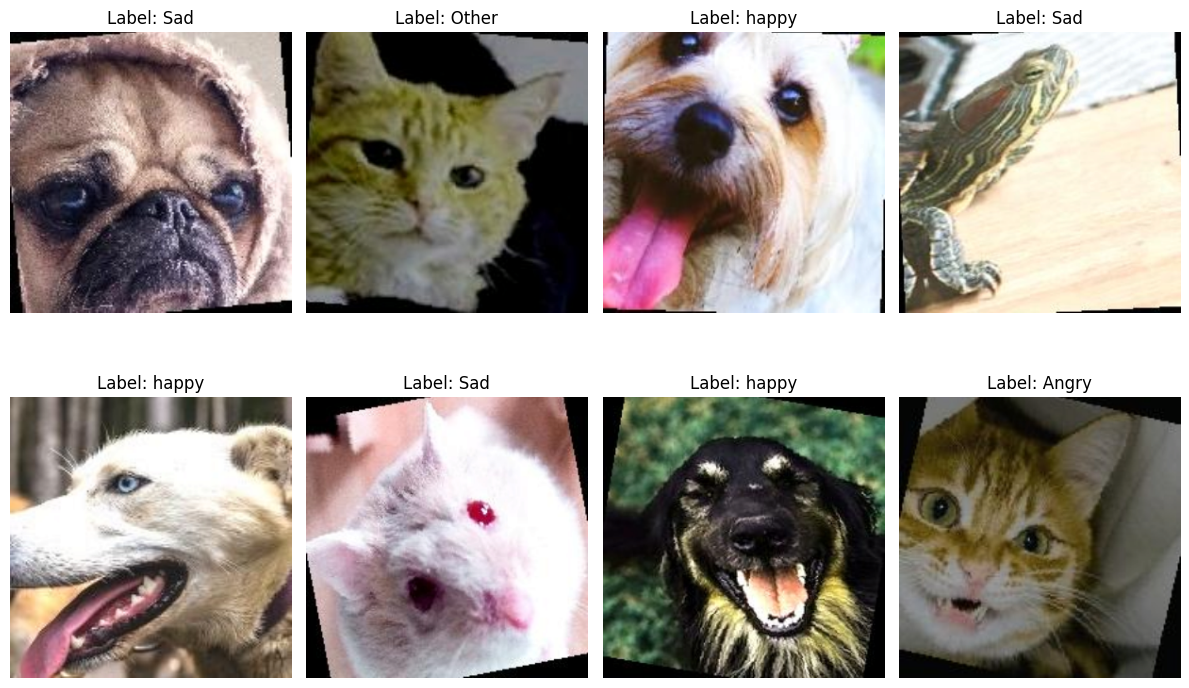

In [3]:
import matplotlib.pyplot as plt
import torchvision.transforms as T

# inverse transform to undo normalization for visualization
inv_transform = T.Compose([
    T.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225]),
    T.ToPILImage()
])

# Fetch a single batch of images and labels
data_iter = iter(train_loader)
images, labels = next(data_iter)

plt.figure(figsize=(12, 8))
for i in range(8):  # Display the first 8 images in the batch
    img = inv_transform(images[i])  # Undo normalization for visualization
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {train_augmented_dataset.classes[labels[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Model architecture

In [4]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class BasicBlock(nn.Module):
    def __init__(self, in_planes, out_planes, dropRate=0.0):
        super(BasicBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.droprate = dropRate

    def forward(self, x):
        out = self.conv1(self.relu(self.bn1(x)))
        if self.droprate > 0:
            out = F.dropout(out, p=self.droprate, training=self.training)
        return torch.cat([x, out], 1)


class BottleneckBlock(nn.Module):
    def __init__(self, in_planes, out_planes, dropRate=0.0):
        super(BottleneckBlock, self).__init__()
        inter_planes = out_planes * 4
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_planes, inter_planes, kernel_size=1, stride=1,
                               padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(inter_planes)
        self.conv2 = nn.Conv2d(inter_planes, out_planes, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.droprate = dropRate

    def forward(self, x):
        out = self.conv1(self.relu(self.bn1(x)))
        if self.droprate > 0:
            out = F.dropout(out, p=self.droprate, inplace=False, training=self.training)
        out = self.conv2(self.relu(self.bn2(out)))
        if self.droprate > 0:
            out = F.dropout(out, p=self.droprate, inplace=False, training=self.training)
        return torch.cat([x, out], 1)


class TransitionBlock(nn.Module):
    def __init__(self, in_planes, out_planes, dropRate=0.0):
        super(TransitionBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=1,
                               padding=0, bias=False)
        self.droprate = dropRate

    def forward(self, x):
        out = self.conv1(self.relu(self.bn1(x)))
        if self.droprate > 0:
            out = F.dropout(out, p=self.droprate, inplace=False, training=self.training)
        return F.avg_pool2d(out, 2)


class DenseBlock(nn.Module):
    def __init__(self, nb_layers, in_planes, growth_rate, block, dropRate=0.0):
        super(DenseBlock, self).__init__()
        self.layer = self._make_layer(block, in_planes, growth_rate, nb_layers, dropRate)

    def _make_layer(self, block, in_planes, growth_rate, nb_layers, dropRate):
        layers = []
        for i in range(nb_layers):
            layers.append(block(in_planes + i * growth_rate, growth_rate, dropRate))
        return nn.Sequential(*layers)

    def forward(self, x):
        return self.layer(x)


class DenseNet121(nn.Module):
    def __init__(self, num_classes, growth_rate=32, reduction=0.5, dropRate=0.0):
        super(DenseNet121, self).__init__()
        block_config = [6, 12, 24, 16]  # DenseNet-121 configuration
        in_planes = 2 * growth_rate

        # Initial convolution
        self.conv1 = nn.Conv2d(3, in_planes, kernel_size=7, stride=2,
                               padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.relu = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Dense Blocks
        self.block1 = DenseBlock(block_config[0], in_planes, growth_rate, BottleneckBlock, dropRate)
        in_planes += block_config[0] * growth_rate
        self.trans1 = TransitionBlock(in_planes, int(in_planes * reduction), dropRate)
        in_planes = int(in_planes * reduction)

        self.block2 = DenseBlock(block_config[1], in_planes, growth_rate, BottleneckBlock, dropRate)
        in_planes += block_config[1] * growth_rate
        self.trans2 = TransitionBlock(in_planes, int(in_planes * reduction), dropRate)
        in_planes = int(in_planes * reduction)

        self.block3 = DenseBlock(block_config[2], in_planes, growth_rate, BottleneckBlock, dropRate)
        in_planes += block_config[2] * growth_rate
        self.trans3 = TransitionBlock(in_planes, int(in_planes * reduction), dropRate)
        in_planes = int(in_planes * reduction)

        self.block4 = DenseBlock(block_config[3], in_planes, growth_rate, BottleneckBlock, dropRate)
        in_planes += block_config[3] * growth_rate

        # Final batch norm
        self.bn2 = nn.BatchNorm2d(in_planes)

        # Classifier
        self.fc = nn.Linear(in_planes, num_classes)

        # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                m.bias.data.zero_()

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.trans1(self.block1(x))
        x = self.trans2(self.block2(x))
        x = self.trans3(self.block3(x))
        x = self.block4(x)
        x = self.relu(self.bn2(x))
        x = F.adaptive_avg_pool2d(x, (1, 1)).view(x.size(0), -1)
        return self.fc(x)


# Implementation training loop

In [6]:
import torch
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
from tqdm import tqdm

# Initialize the InceptionV3 model
model = DenseNet121(num_classes=4)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []
train_precisions = []
train_recalls = []
train_f1s = []
train_conf_matrices = []

val_losses = []
val_accuracies = []
val_precisions = []
val_recalls = []
val_f1s = []
val_conf_matrices = []

# Training loop with progress bar
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        logits = outputs

        # Calculate loss
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, preds = torch.max(logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Store predictions and labels for metric calculations
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    # Calculate precision, recall, F1 score, and confusion matrix
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, conf_matrix

# Validation loop with progress bar
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            logits = outputs

            # Calculate loss
            loss = criterion(logits, labels)
            running_loss += loss.item()

            # Calculate accuracy
            _, preds = torch.max(logits, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Store predictions and labels for metric calculations
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    # Calculate precision, recall, F1 score, and confusion matrix
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, conf_matrix

# Training loop
def train(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    best_val_accuracy = 0.0
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Train for one epoch
        train_loss, train_accuracy, train_precision, train_recall, train_f1, train_conf_matrix = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        train_precisions.append(train_precision)
        train_recalls.append(train_recall)
        train_f1s.append(train_f1)
        train_conf_matrices.append(train_conf_matrix)

        # Validate after training
        val_loss, val_accuracy, val_precision, val_recall, val_f1, val_conf_matrix = validate_epoch(model, val_loader, criterion, device)
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)
        val_f1s.append(val_f1)
        val_conf_matrices.append(val_conf_matrix)

        # Save the best model based on validation accuracy
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), "best_implemented_densenet_121.pth")
            print("Saved best model!")

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Train the model
train(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=40)

Epoch 1/40


Training:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Training Loss: 1.3990, Training Accuracy: 0.3093


Validation:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Validation Loss: 1.3962, Validation Accuracy: 0.3056
Saved best model!
Epoch 2/40


...

Validation Loss: 3.1786, Validation Accuracy: 0.3056
Epoch 40/40


Training:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Training Loss: 0.0473, Training Accuracy: 0.9842


Validation:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
                                                         

Validation Loss: 2.5226, Validation Accuracy: 0.3333


In [7]:
print("Best validation accuracy", max(val_accuracies))

Best validation accuracy 0.4722222222222222


# Implementation performance graphs

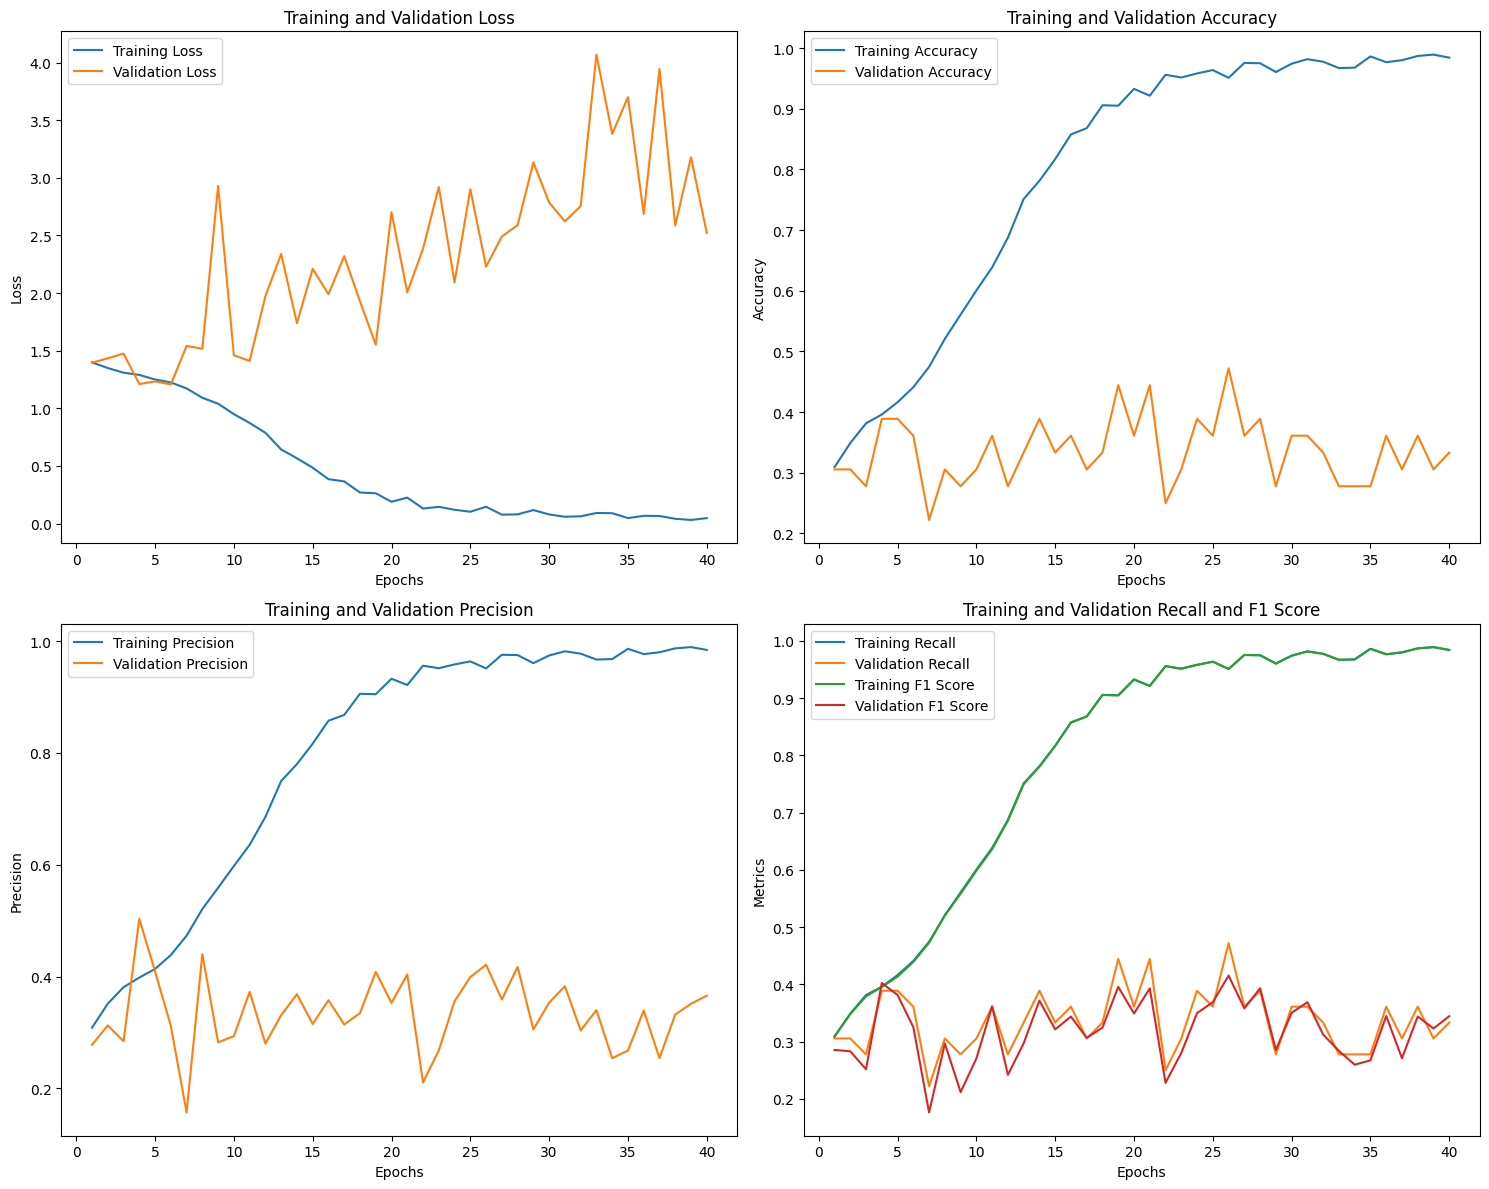

In [8]:
import matplotlib.pyplot as plt

def plot_metrics():
    epochs = range(1, len(train_losses) + 1)

    # Plot training and validation loss
    plt.figure(figsize=(15, 12))

    plt.subplot(2, 2, 1)
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    # Plot training and validation accuracy
    plt.subplot(2, 2, 2)
    plt.plot(epochs, train_accuracies, label='Training Accuracy')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')

    # Plot precision, recall, and F1 scores for training and validation
    plt.subplot(2, 2, 3)
    plt.plot(epochs, train_precisions, label='Training Precision')
    plt.plot(epochs, val_precisions, label='Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.legend()
    plt.title('Training and Validation Precision')

    plt.subplot(2, 2, 4)
    plt.plot(epochs, train_recalls, label='Training Recall')
    plt.plot(epochs, val_recalls, label='Validation Recall')
    plt.plot(epochs, train_f1s, label='Training F1 Score')
    plt.plot(epochs, val_f1s, label='Validation F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.legend()
    plt.title('Training and Validation Recall and F1 Score')

    plt.tight_layout()
    plt.show()

plot_metrics()

# Implementation performance visualization

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Performance on training images


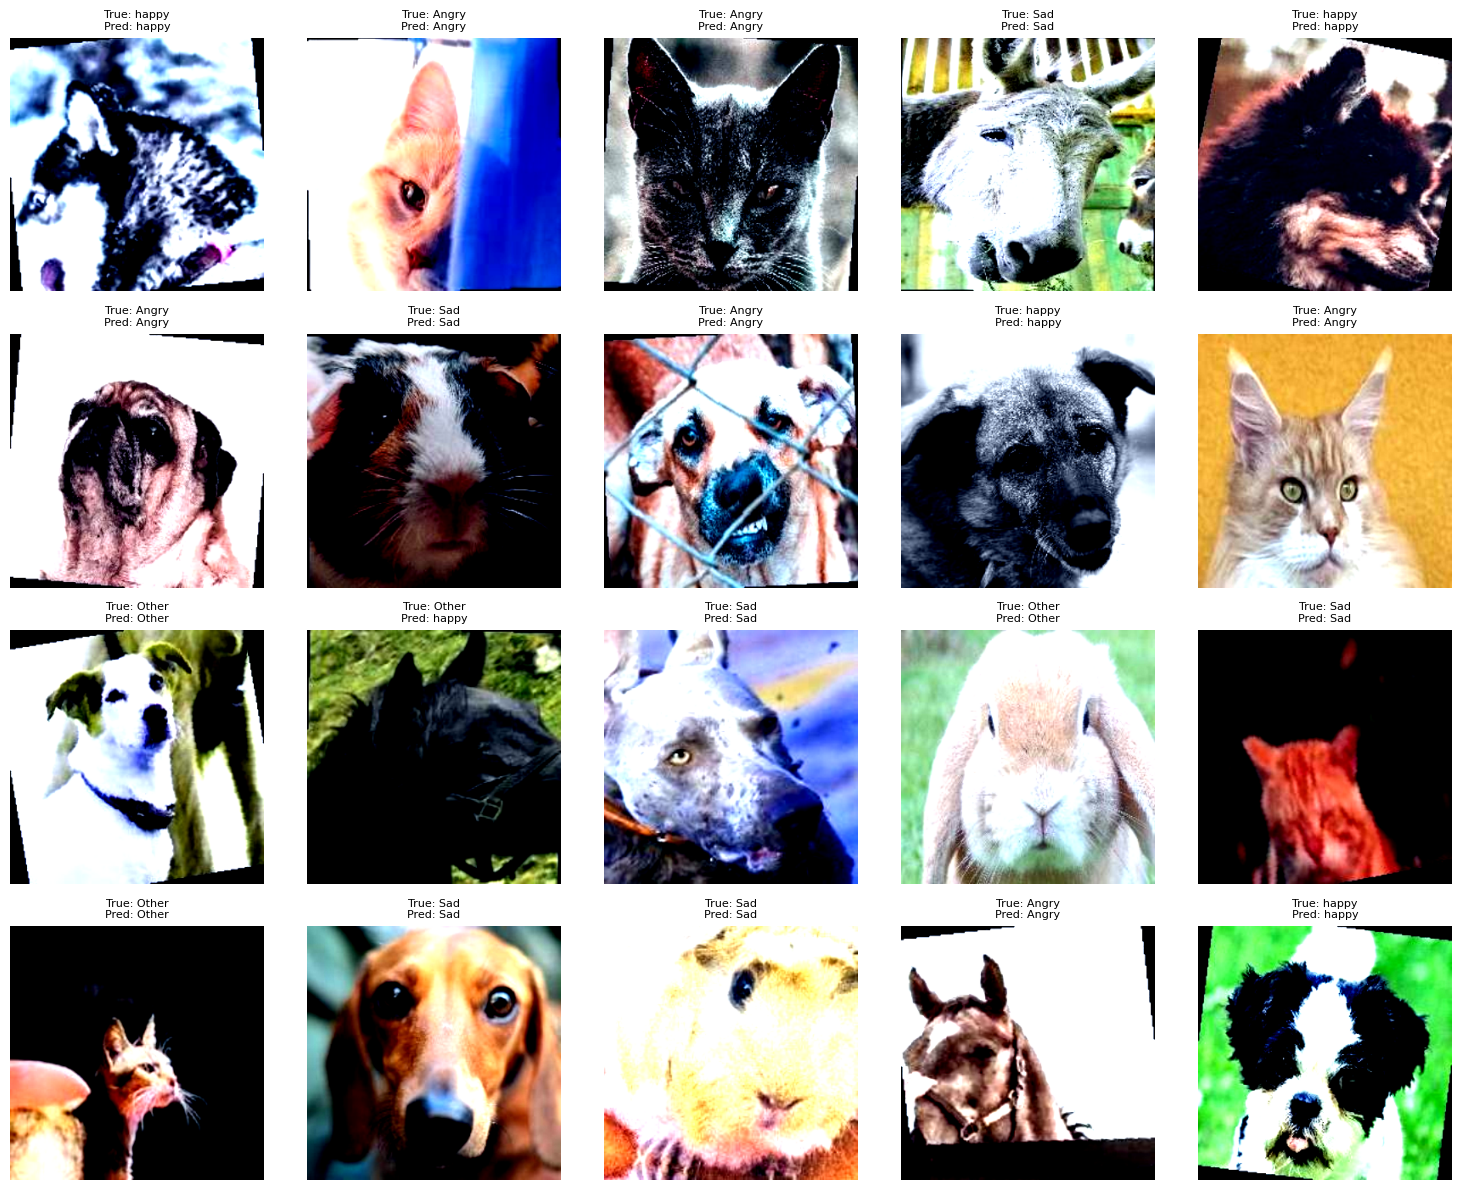

Performance on validation images


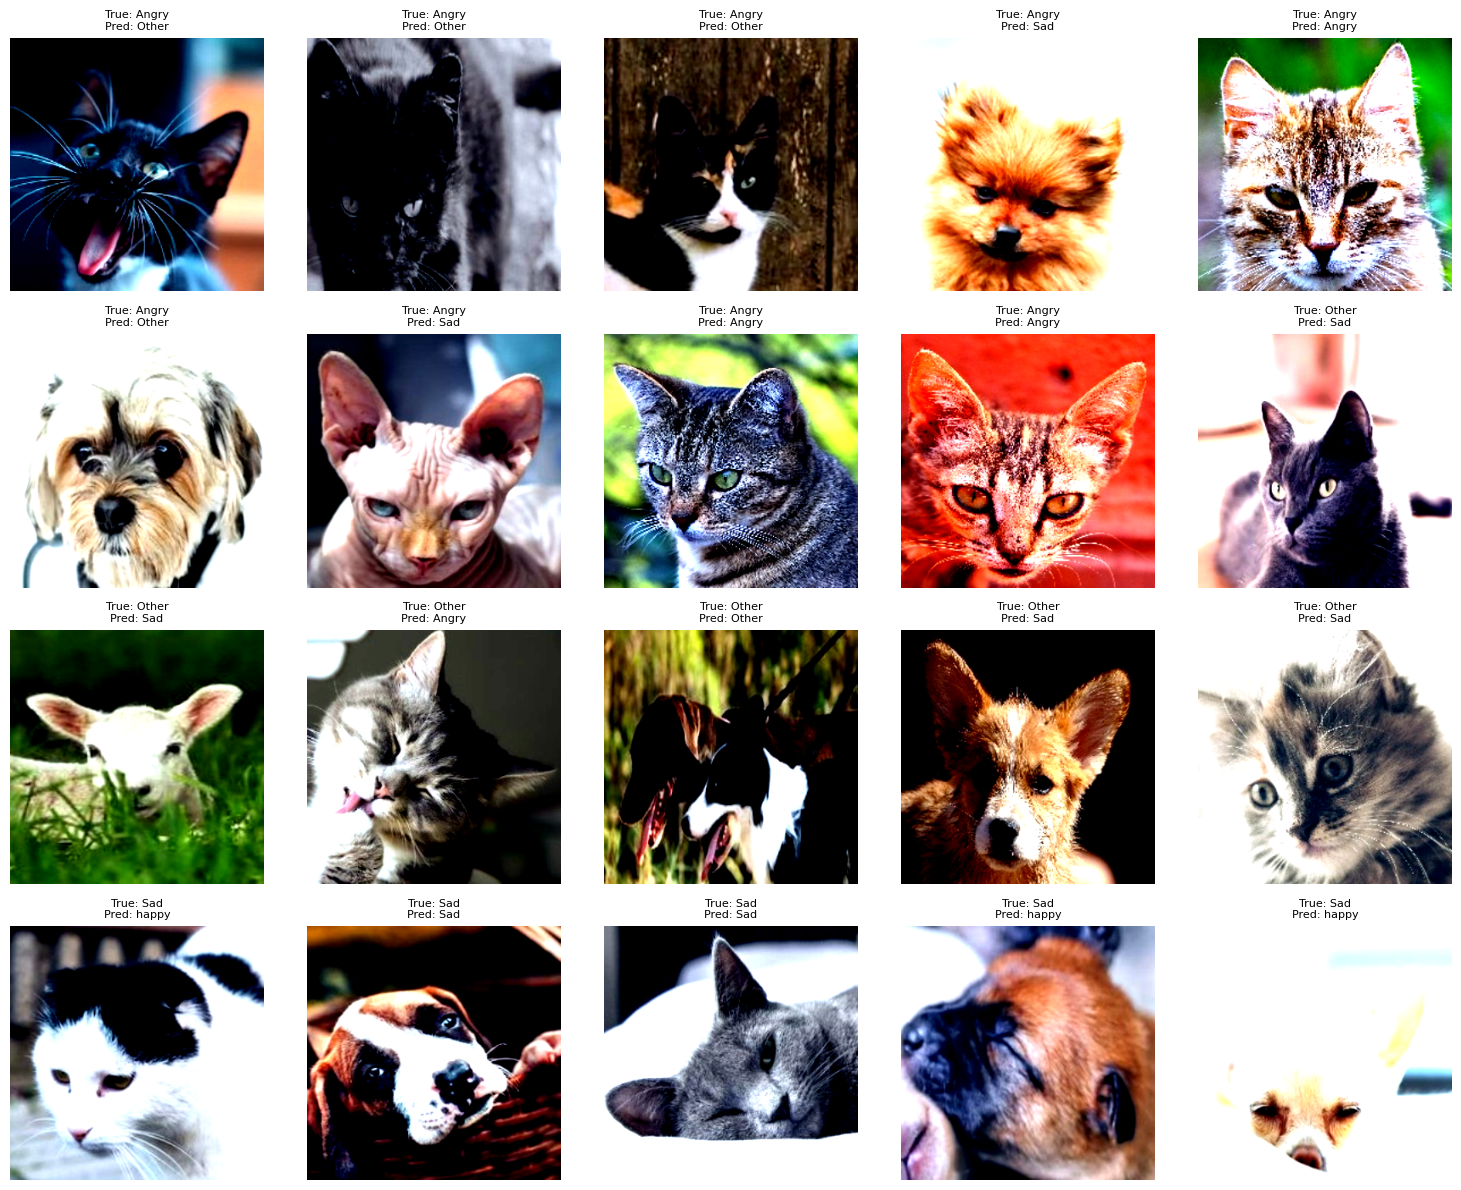

In [10]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms

# Define a helper function to display a batch of images in a grid
def show_images_in_grid(images, true_labels, pred_labels, class_names, num_images=20):
    # Create a 4x5 grid
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.flatten()  # Flatten the 2D array of axes to make it easier to iterate

    for i in range(num_images):
        image = images[i].permute(1, 2, 0).cpu().numpy()  # Convert to HWC format
        image = (image + 1) / 2 if image.min() < 0 else image  # Rescale if normalized
        image = np.clip(image, 0, 1)  # Ensure image is in the valid range

        # Get true and predicted labels
        true_label = true_labels[i].item()
        pred_label = pred_labels[i]

        # Display the image with its true and predicted labels
        axes[i].imshow(image)
        axes[i].axis('off')  # Hide the axes
        axes[i].set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", fontsize=8)

    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

# Define function to get predictions from the model
def get_predictions(model, dataloader, device, num_images=20):
    model.eval()
    images = []
    true_labels = []
    pred_labels = []

    # Iterate over the dataloader to get a few examples
    for i, (image_batch, label_batch) in enumerate(dataloader):
        if i == 0:  # Take only the first batch
            images = image_batch[:num_images].to(device)
            true_labels = label_batch[:num_images].to(device)
            outputs = model(images)

            logits = outputs
            _, predicted = torch.max(logits, 1)
            pred_labels = predicted[:num_images].cpu().numpy()

            break

    return images, true_labels, pred_labels

# Load class names (replace this with the actual class names of your dataset)
class_names = train_augmented_dataset.classes

# Get predictions and display 20 images from the training dataset
train_images, train_labels, train_preds = get_predictions(model, train_loader, device, num_images=20)
print("Performance on training images")
show_images_in_grid(train_images, train_labels, train_preds, class_names, num_images=20)

# Get predictions and display 20 images from the validation dataset
val_images, val_labels, val_preds = get_predictions(model, val_loader, device, num_images=20)
print("Performance on validation images")
show_images_in_grid(val_images, val_labels, val_preds, class_names, num_images=20)

# Pretrained model training loop

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import densenet121
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
from tqdm import tqdm

# Load the pretrained DenseNet-121 model
pretrained_model = densenet121(pretrained=True)

# Modify the final classification layer for the specific number of classes (e.g., 1000 -> 4 for example)
num_classes = 4  # Change this to match your dataset
pretrained_model.classifier = nn.Linear(pretrained_model.classifier.in_features, num_classes)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pretrained_model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []
train_precisions = []
train_recalls = []
train_f1s = []
train_conf_matrices = []

val_losses = []
val_accuracies = []
val_precisions = []
val_recalls = []
val_f1s = []
val_conf_matrices = []

# Training loop with progress bar
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Store predictions and labels for metric calculations
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    # Calculate precision, recall, F1 score, and confusion matrix
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, conf_matrix

# Validation loop with progress bar
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Calculate accuracy
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Store predictions and labels for metric calculations
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    # Calculate precision, recall, F1 score, and confusion matrix
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, conf_matrix

# Training loop
def train(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    best_val_accuracy = 0.0
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Train for one epoch
        train_loss, train_accuracy, train_precision, train_recall, train_f1, train_conf_matrix = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        train_precisions.append(train_precision)
        train_recalls.append(train_recall)
        train_f1s.append(train_f1)
        train_conf_matrices.append(train_conf_matrix)

        # Validate after training
        val_loss, val_accuracy, val_precision, val_recall, val_f1, val_conf_matrix = validate_epoch(model, val_loader, criterion, device)
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)
        val_f1s.append(val_f1)
        val_conf_matrices.append(val_conf_matrix)

        # Save the best model based on validation accuracy
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), "best_pretrained_densenet_121.pth")
            print("Saved best model!")

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pretrained_model = pretrained_model.to(device)

# Train the model
train(pretrained_model, train_loader, val_loader, criterion, optimizer, device, num_epochs=40)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 123MB/s]


Epoch 1/40


Training Loss: 1.0542, Training Accuracy: 0.5547


Validation:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Validation Loss: 1.6678, Validation Accuracy: 0.5278
Saved best model!
Epoch 2/40


...

Validation Loss: 3.0389, Validation Accuracy: 0.5556
Epoch 40/40


Training:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Training Loss: 0.0003, Training Accuracy: 1.0000


Validation:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
                                                         

Validation Loss: 3.0468, Validation Accuracy: 0.4722


In [12]:
print("Best validation accuracy", max(val_accuracies))

Best validation accuracy 0.6111111111111112


# Pretrained model performance graphs

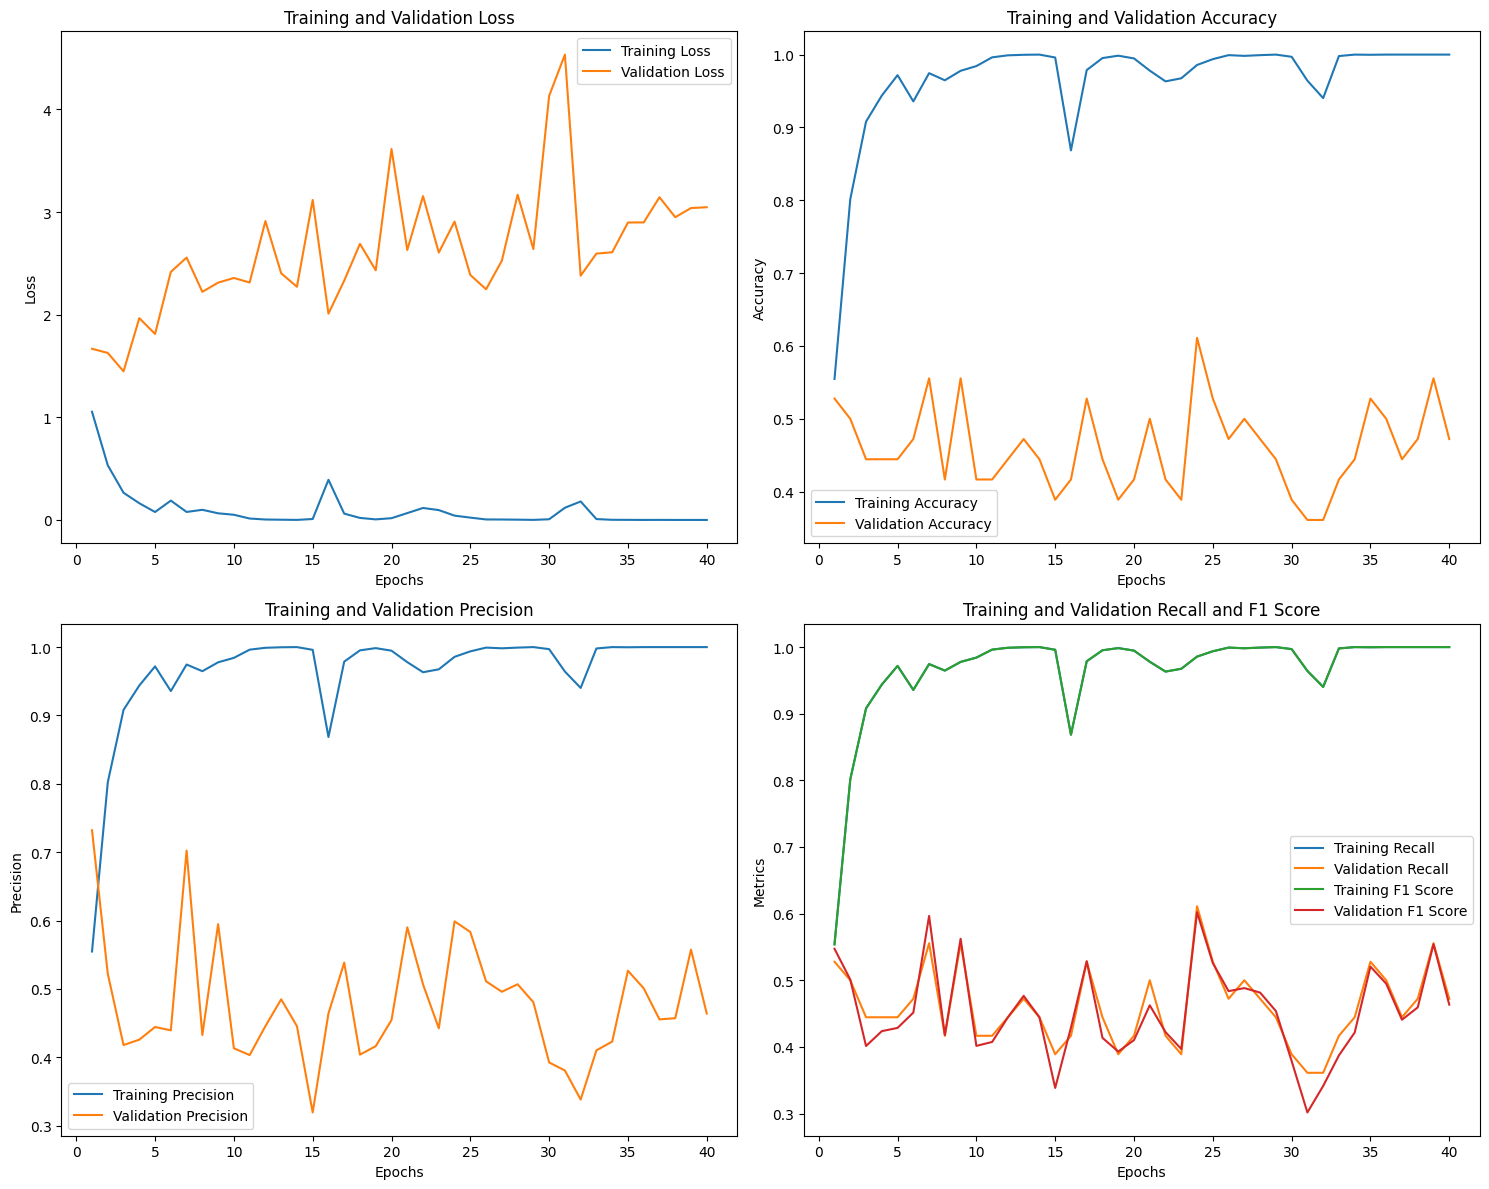

In [13]:
import matplotlib.pyplot as plt

def plot_metrics():
    epochs = range(1, len(train_losses) + 1)

    # Plot training and validation loss
    plt.figure(figsize=(15, 12))

    plt.subplot(2, 2, 1)
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    # Plot training and validation accuracy
    plt.subplot(2, 2, 2)
    plt.plot(epochs, train_accuracies, label='Training Accuracy')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')

    # Plot precision, recall, and F1 scores for training and validation
    plt.subplot(2, 2, 3)
    plt.plot(epochs, train_precisions, label='Training Precision')
    plt.plot(epochs, val_precisions, label='Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.legend()
    plt.title('Training and Validation Precision')

    plt.subplot(2, 2, 4)
    plt.plot(epochs, train_recalls, label='Training Recall')
    plt.plot(epochs, val_recalls, label='Validation Recall')
    plt.plot(epochs, train_f1s, label='Training F1 Score')
    plt.plot(epochs, val_f1s, label='Validation F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.legend()
    plt.title('Training and Validation Recall and F1 Score')

    plt.tight_layout()
    plt.show()

plot_metrics()

# Implementation and pretrained models' performance on test data

## Pretrained model

In [16]:
def evaluate_on_test(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing", leave=False):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            logits = outputs

            # Calculate loss
            loss = criterion(logits, labels)
            running_loss += loss.item()

            # Calculate accuracy
            _, preds = torch.max(logits, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Store predictions and labels for metric calculations
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(test_loader)
    accuracy = correct / total

    # Calculate precision, recall, F1 score, and confusion matrix
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    print(f"\nTest Loss: {avg_loss:.4f}\n Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}\n Test Recall: {recall:.4f}")
    print(f"Test F1 Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}")

best_model = DenseNet121(num_classes=4)
best_model.load_state_dict(torch.load("best_implemented_densenet_121.pth"))
best_model = best_model.to(device)

best_pretrained_model = densenet121(pretrained=True)
num_classes = 4
best_pretrained_model.classifier = nn.Linear(best_pretrained_model.classifier.in_features, num_classes)
best_pretrained_model.load_state_dict(torch.load("best_pretrained_densenet_121.pth"))
best_pretrained_model = best_pretrained_model.to(device)

print("Implemented model performance: ")
evaluate_on_test(best_model, test_loader, criterion, device)

print("\nPretrained model performance: ")
evaluate_on_test(best_pretrained_model, test_loader, criterion, device)

<ipython-input-16-9688e4c8d5b6>:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load("best_implemented_densenet_121.pth"))
<ipython-input-

Implemented model performance: 


Testing:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Test Loss: 5.3772
 Test Accuracy: 0.1316
Test Precision: 0.1224
 Test Recall: 0.1316
Test F1 Score: 0.1268
Confusion Matrix:
[[2 1 2 5]
 [2 0 3 1]
 [3 3 1 4]
 [4 0 5 2]]

Pretrained model performance: 


Testing:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
                                                      


Test Loss: 2.2896
 Test Accuracy: 0.5263
Test Precision: 0.5281
 Test Recall: 0.5263
Test F1 Score: 0.5216
Confusion Matrix:
[[4 1 2 3]
 [1 3 2 0]
 [2 2 5 2]
 [0 0 3 8]]
